In [3]:
suppressMessages(library(ggplot2))
suppressMessages(library(tidyr))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(Seurat))
suppressMessages(library(reshape))
suppressMessages(library(readxl))

In [4]:
bulk_brca1 <- readRDS("final_brca1_wt_tumors_seurat5.rds")

In [5]:
# export to Scanpy for plotting

# save metadata table:
bulk_brca1$barcode <- colnames(bulk_brca1)
write.csv(bulk_brca1@meta.data, file='nathanson.metadata.csv', quote=F,row.names=F)

# write expression counts matrix
library(Matrix)
counts_matrix <- GetAssayData(bulk_brca1, assay='RNA', slot='counts')
writeMM(counts_matrix, file='nathanson.counts.mtx')

# write gene names
write.table(
  data.frame('gene'=rownames(counts_matrix)),file='nathanson.gene.names.csv',
  quote=F,row.names=F,col.names=F
) 


Attaching package: ‘Matrix’


The following object is masked from ‘package:reshape’:

    expand


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


NULL

In [45]:
colnames(bulk_brca1[[]])

[1] "orig.ident"             "nCount_RNA"             "nFeature_RNA"          
 [4] "Group"                  "Receptor"               "Mutation"              
 [7] "Primary_Recurrent"      "Treatment"              "batch"                 
[10] "final_subtype"          "wap_cre_deg_all_cells1" "subtype_M_or_other"    
[13] "blg_cre_deg_all_cells1"

In [4]:
blg_cre_deg <- read.csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/merged_scanpy/blg_sig_degs_aneuploid_tumor_vs_normal_sampled_epi_wilcox.csv", row.names = 1)

In [4]:
wap_cre_deg <- read.csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/merged_scanpy/wap_sig_degs_aneuploid_tumor_vs_normal_sampled_epi_wilcox.csv", row.names = 1)

In [5]:
head(blg_cre_deg)

,names,scores,logfoldchanges,pvals,pvals_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,B2m,61.50663,4.904831,0,0
1,Capza2,59.81401,4.560444,0,0
2,Tes,59.54570,5.212900,0,0
3,Met,55.40713,4.345796,0,0
4,H2-Q7,55.14730,5.009435,0,0
5,Crip1,53.59105,3.878141,0,0


In [5]:
mouse_human_genes = readRDS("/share/crsp/lab/dalawson/tzhuravl/TCGA/mouse_human_genes.rds")

mouse <- mouse_human_genes[which(mouse_human_genes['Common.Organism.Name']=="mouse, laboratory"),c(1,4)]
mouse = mouse[!duplicated(mouse$Symbol),]
dim(mouse)

human <- mouse_human_genes[which(mouse_human_genes['Common.Organism.Name']=="human"),c(1,4)]
human = human[!duplicated(human$Symbol),]
dim(human)

df_merge <- merge(human,mouse,by="DB.Class.Key")
dim(df_merge)

[1] 21810     2

[1] 19324     2

[1] 19323     3

In [7]:
x <- blg_cre_deg$names
output = c()

test <- for (i in 1:length(x)) {  
  if (x[i] %in% df_merge$Symbol.y) {
      y <- which(df_merge$Symbol.y == x[i])
      y <- y[1]
      output = append(output,df_merge[y,2])
    } else {output = append(output,x[i])}
}

length(output)


genes_upper <- sapply(X = output, FUN = function(x) {
    x <- str_to_upper(x)
})

genes_upper <- as.data.frame(genes_upper)

blg_cre_deg$names <- genes_upper$genes_upper

head(blg_cre_deg)

[1] 989

,names,scores,logfoldchanges,pvals,pvals_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,B2M,61.50663,4.904831,0,0
1,CAPZA2,59.81401,4.560444,0,0
2,TES,59.54570,5.212900,0,0
3,MET,55.40713,4.345796,0,0
4,H2-Q7,55.14730,5.009435,0,0
5,CRIP1,53.59105,3.878141,0,0


In [6]:
x <- wap_cre_deg$names
output = c()

test <- for (i in 1:length(x)) {  
  if (x[i] %in% df_merge$Symbol.y) {
      y <- which(df_merge$Symbol.y == x[i])
      y <- y[1]
      output = append(output,df_merge[y,2])
    } else {output = append(output,x[i])}
}

length(output)


genes_upper <- sapply(X = output, FUN = function(x) {
    x <- str_to_upper(x)
})

genes_upper <- as.data.frame(genes_upper)

wap_cre_deg$names <- genes_upper$genes_upper

head(wap_cre_deg)

[1] 1185

,names,scores,logfoldchanges,pvals,pvals_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,CDKN2A,52.02663,5.536285,0,0
1,LGALS7,43.11890,2.827310,0,0
2,COL9A3,43.06892,3.294412,0,0
3,FTH1,42.79489,1.677731,0,0
4,MOXD1,40.91815,3.615898,0,0
5,GAPDH,40.64762,1.683253,0,0


In [8]:
write.csv(blg_cre_deg, "as_human_blg_sig_degs_aneuploid_tumor_vs_normal_sampled_epi_wilcox.csv")

In [7]:
write.csv(wap_cre_deg, "as_human_wap_sig_degs_aneuploid_tumor_vs_normal_sampled_epi_wilcox.csv")

<h1 id="No-BRCA2">No BRCA2, no ER+</h1>

## normalize

In [8]:
bulk_brca1 <- NormalizeData(bulk_brca1)

Normalizing layer: counts



In [47]:
bulk_brca1

An object of class Seurat 
35479 features across 51 samples within 1 assay 
Active assay: RNA (35479 features, 0 variable features)
 2 layers present: counts, data

In [48]:
bulk_brca1 <- AddModuleScore(
  bulk_brca1,
  features = list(blg_cre_deg$names),
  pool = NULL,
  nbin = 24,
  ctrl = 100,
  k = FALSE,
  assay = NULL,
  name = "blg_cre_deg",
  seed = 1,
  search = FALSE,
  slot = "data"
)

Warning message:
“The following features are not present in the object: H2-Q7, GM10709, H2-D1, H2-K1, APOL9A, H2-Q4, IFI203, IFI27L2A, APOL9B, WFDC18, H2-T22, 1810011O10RIK, 1110008P14RIK, OASL2P, H1-0, FOXC1, MNDAL, C15ORF48, GM12840, AU020206, IFI204, C1ORF21, SNHG18, 0610012G03RIK, GM8797, SEPT9, 2810474O19RIK, TNFRSF23, 3222401L13RIK, LYZ2, IFI202B, PVRL4, SCD2, H2-EB1, APOL7A, SLFN2, SNHG20, C1ORF53, HIST1H2AP, 2610035D17RIK, AI607873, H19, 1700016C15RIK, GM16586, C15ORF62, 5031425E22RIK, 4930402H24RIK, IGTP, GM44269, A330069E16RIK, ALOX12E, A630023A22RIK, CYP2D22, GM4951, A230050P20RIK, IRGM1, GGTA1, IFI47, 2010005H15RIK, OAS1A, LOCKD, METTL20, WFDC17, PHF11D, C16ORF74, C11ORF54, CYP2D10, GM4876, GPR137B-PS, 2310001H17RIK, WBSCR25, GM7160, HOTAIRM1, GM22, FBXW17, RAB26OS, GM17056, GM10138, GM15473, B930036N10RIK, C4ORF19, IIGP1, 2810417H13RIK, RP23-299D2.2, E130102H24RIK, TRIM12C, GM26670, TRIM30A, SECTM1A, GM8439, C16ORF89, XLR3B, GRRP1, GBP9, 3110062M04RIK, D130051D11RIK, TAGAP

In [9]:
bulk_brca1 <- AddModuleScore(
  bulk_brca1,
  features = list(wap_cre_deg$names),
  pool = NULL,
  nbin = 24,
  ctrl = 100,
  k = FALSE,
  assay = NULL,
  name = "wap_cre_deg",
  seed = 1,
  search = FALSE,
  slot = "data"
)

Warning message:
“The following features are not present in the object: GM20275, SNORC, SNHG18, GM45237, WFDC18, ZNRD2, GM31045, C16ORF74, C1ORF53, C21ORF91, SCD2, SNHG6, IFI27L2A, MIR205HG, AHSA2P, MIR100HG, 4933406J09RIK, C11ORF54, FOXC1, GM45589, CATSPERZ, 4930420G21RIK, INAVA, CFAP410, E130309D02RIK, GM38560, INKA1, GM33651, H2-Q7, XLR4B, TLNRD1, 5033430I15RIK, XLR4A, OTULINL, E330020D12RIK, PCLAF, C2ORF88, E030030I06RIK, OASL2P, TEDC1, GM4258, LOCKD, D730045B01RIK, LBHD2, GGTA1, SPAAR, GM45238, DIPK1B, GM30018, CENPS, GM12840, GM15987, BC018473, ZFP951, APOL9A, A330048O09RIK, IRGM1, GM5095, C630043F03RIK, GM16740, GM50223, 2810429I04RIK, GM42067, 4931429P17RIK, B530045E10RIK, GM13481, GM9844, CABCOCO1, HIST1H2AP, WDR95, OLFR1369-PS1, GM4117, TAGAP1, 2900089D17RIK, IFI47, GM20559, PACC1, GM47865, IFI202B, 4833423E24RIK, GM47509, APOL9B, 4932438H23RIK, CIP2A, GRRP1, GM14964, RNF227, GNAS-AS1, HOTAIRM1, 1500002F19RIK, 2010204K13RIK, GM24474, 2810408I11RIK, 1700012B07RIK, CASTOR1, GM4

In [10]:
quantile(bulk_brca1$wap_cre_deg1, probs = c(0.9))

90% 
0.03871545

In [79]:
bulk_brca1$misc <- "bulk_Nathanson"

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


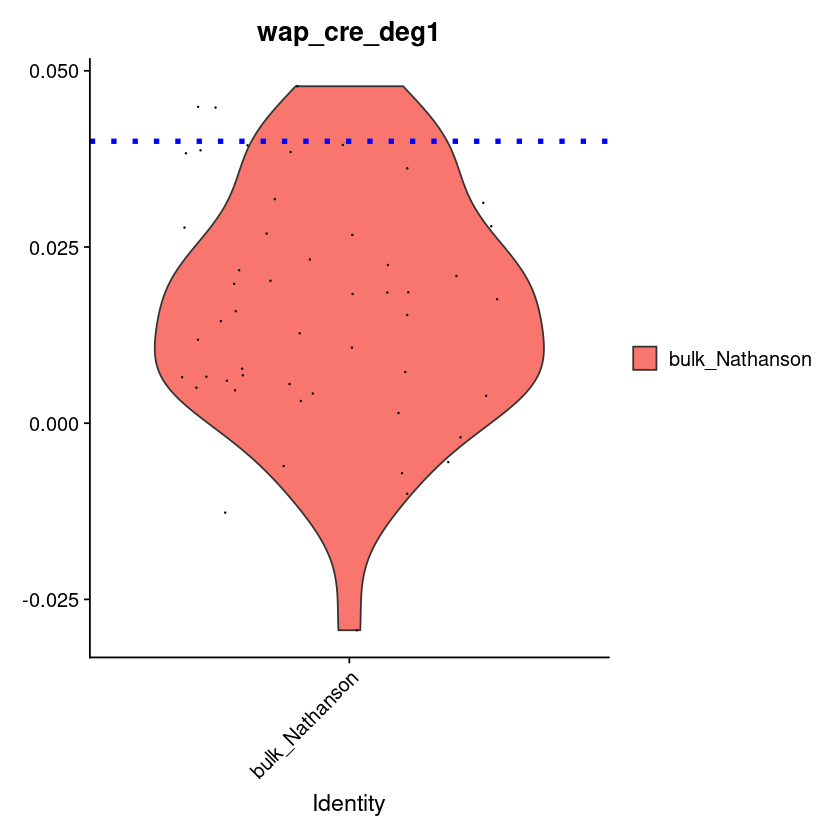

In [11]:
VlnPlot(bulk_brca1, "wap_cre_deg1", group.by = "misc")+ 
geom_hline(yintercept = 0.04, linetype="dotted", 
                color = "blue", size=1.5)

In [12]:
bulk_brca1@meta.data$mouse_blg_like <- "not"
bulk_brca1@meta.data[which(bulk_brca1@meta.data$wap_cre_deg1 > 0.04),'mouse_blg_like'] <- "mouse_blg_like"

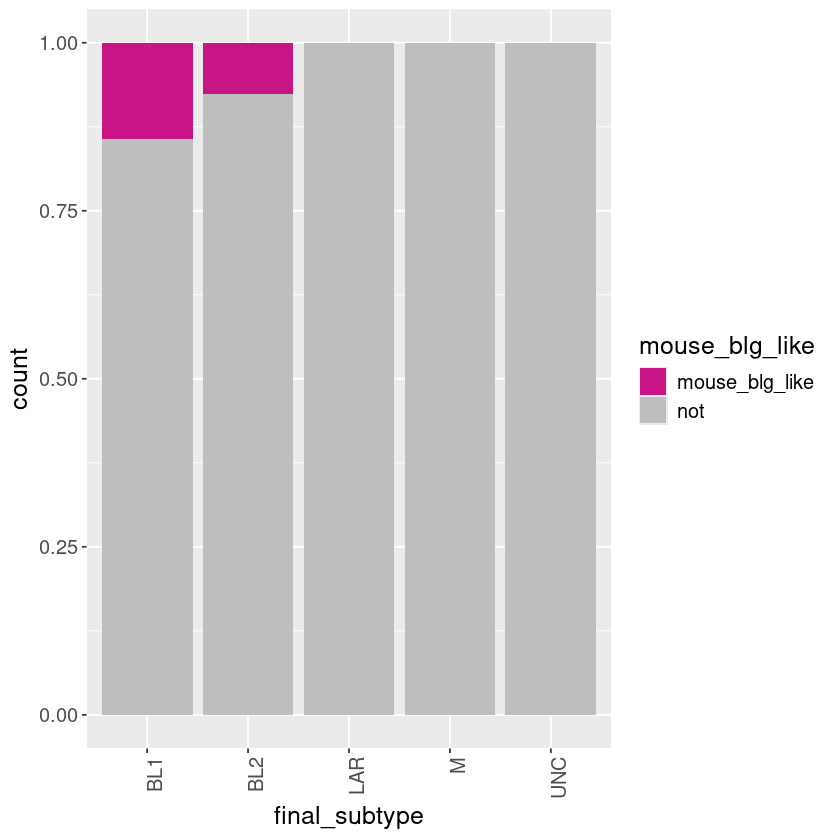

In [13]:
ggplot(bulk_brca1@meta.data, aes(x=final_subtype,
                          fill=mouse_blg_like)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 90, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ 
scale_fill_manual(values=c("mediumvioletred","grey"))

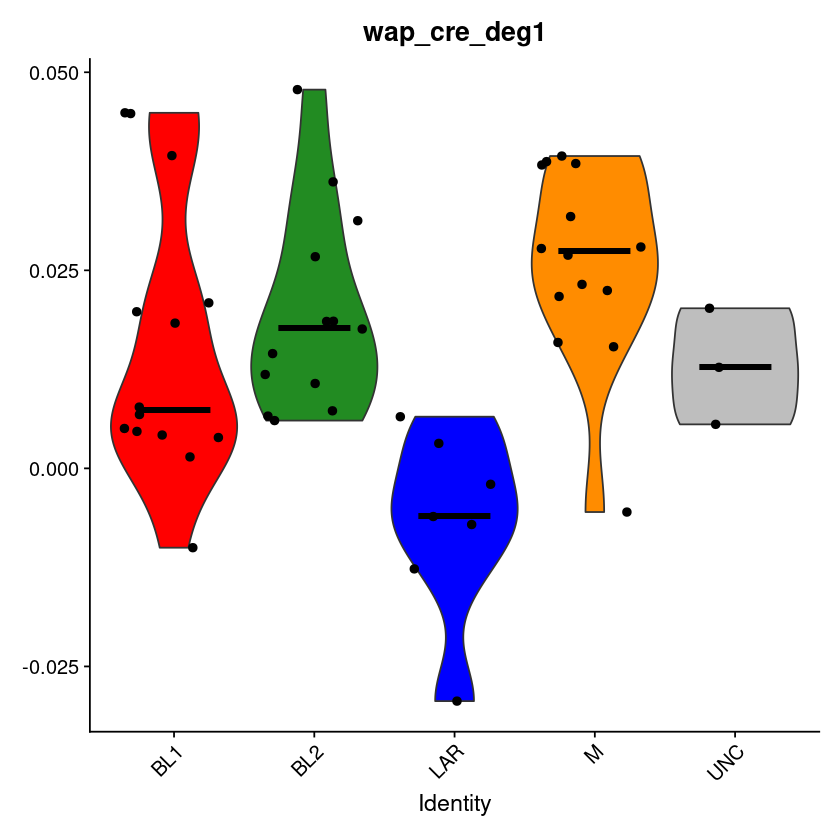

In [14]:
#pdf("score_by_subtype_violins_median.pdf")
VlnPlot(bulk_brca1, "wap_cre_deg1", 
        group.by = "final_subtype", pt.size=2,
       cols=c("red","forestgreen","blue","darkorange","grey"))+
    stat_summary(fun = median, geom='point', size = 25, colour = "black", shape = 95)+NoLegend()
#dev.off()

In [15]:
bulk_brca1$final_subtype <- factor(bulk_brca1$final_subtype, levels = c("BL1", "BL2", "LAR", "M", "UNC"))

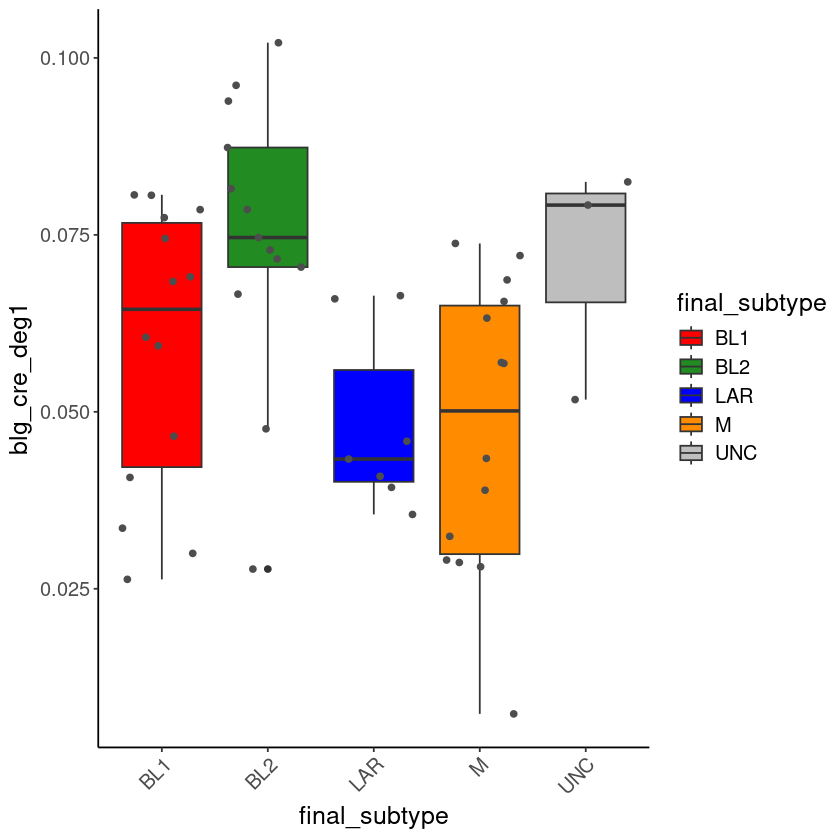

In [59]:
#pdf("score_by_subtype_violins_median.pdf",width=8, height=7)
ggplot(data = bulk_brca1[[]], aes(x=final_subtype, y=blg_cre_deg1)) + geom_boxplot(aes(fill=final_subtype))+ 
theme_classic()+
scale_fill_manual(values=c("red","forestgreen","blue","darkorange","grey"))+
theme(text = element_text(size = 15))+
geom_jitter(alpha = 5, color = "grey30")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
#dev.off()

In [61]:
bulk_brca1$subtype_mutation <- paste(bulk_brca1$final_subtype, bulk_brca1$Mutation, sep = "_")

In [62]:
Idents(bulk_brca1) <- "subtype_mutation"
bulk_brca1 <- RenameIdents(bulk_brca1, 
                            `BL1_BRCA1` = "non_M", 
                            `BL1_WT` = "non_M", 
                            `BL2_BRCA1` = "non_M", 
                            `LAR_BRCA1` = "non_M",
                            `LAR_WT` = "non_M",
                            `M_BRCA1` = "M_BRCA1",
                            `M_WT` = "M_WT", 
                            `UNC_BRCA1` = "non_M", 
                            `UNC_WT` = "non_M")
bulk_brca1$subtype_mutation_other <- bulk_brca1@active.ident

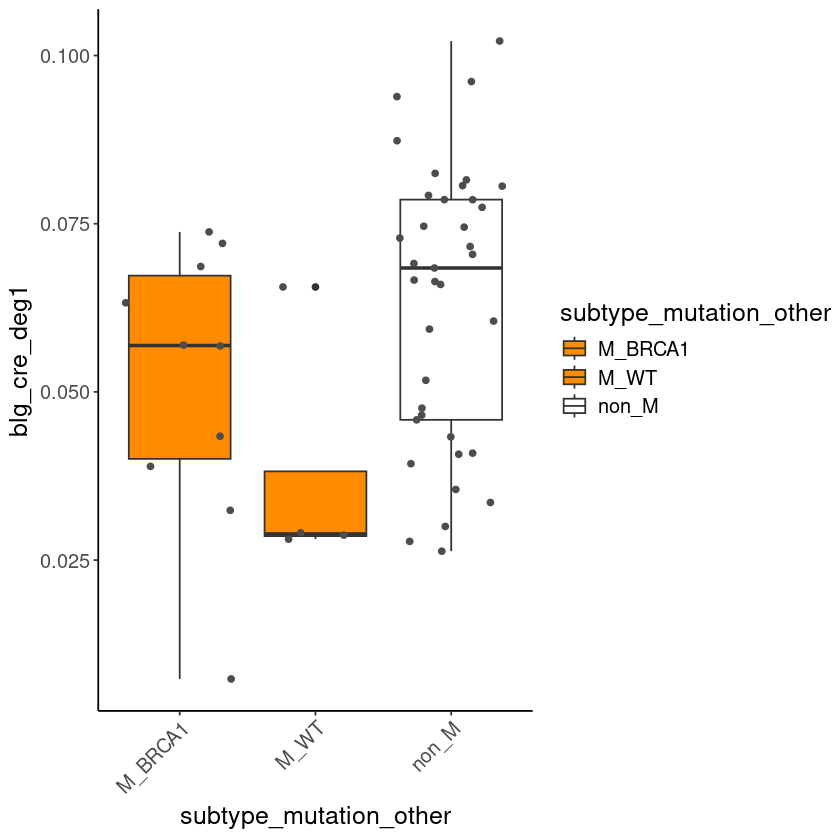

In [65]:
bulk_brca1$subtype_mutation_other <- factor(bulk_brca1$subtype_mutation_other, levels = c("M_BRCA1", "M_WT", "non_M"))

#pdf("blg_aneu_score_by_subtype_mutation_other.pdf",width=7, height=7)
ggplot(data = bulk_brca1[[]], aes(x=subtype_mutation_other, y=blg_cre_deg1)) + geom_boxplot(aes(fill=subtype_mutation_other))+ 
theme_classic()+
scale_fill_manual(values=c("darkorange","darkorange","white"))+
theme(text = element_text(size = 15))+
geom_jitter(alpha = 5, color = "grey30")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
#dev.off()

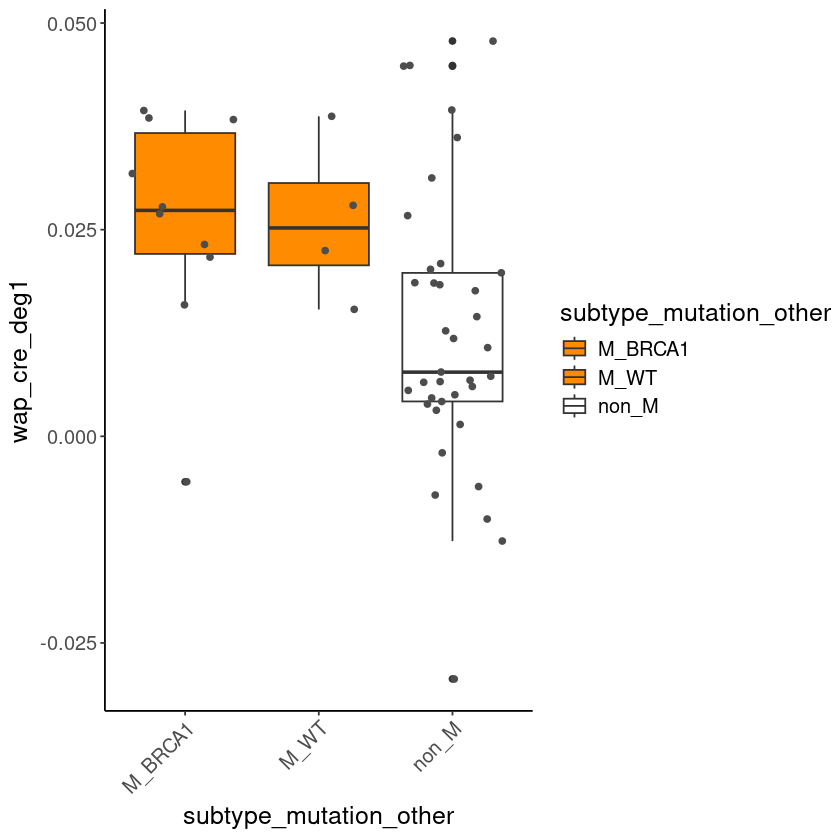

In [27]:
bulk_brca1$subtype_mutation_other <- factor(bulk_brca1$subtype_mutation_other, levels = c("M_BRCA1", "M_WT", "non_M"))

#pdf("wap_aneu_score_by_subtype_mutation_other.pdf",width=7, height=7)
ggplot(data = bulk_brca1[[]], aes(x=subtype_mutation_other, y=wap_cre_deg1)) + geom_boxplot(aes(fill=subtype_mutation_other))+ 
theme_classic()+
scale_fill_manual(values=c("darkorange","darkorange","white"))+
theme(text = element_text(size = 15))+
geom_jitter(alpha = 5, color = "grey30")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
#dev.off()

In [33]:
Idents(bulk_brca1) <- "subtype"
bulk_brca1 <- RenameIdents(object = bulk_brca1, 
                            "BL1" = "TNBC_other", 
                            "BL2" = "TNBC_other", 
                            "LAR" = "TNBC_other", 
                            "M" = "TNBC_M",
                            "UNC" = "TNBC_other")
bulk_brca1$subtype_M_or_other <- bulk_brca1@active.ident

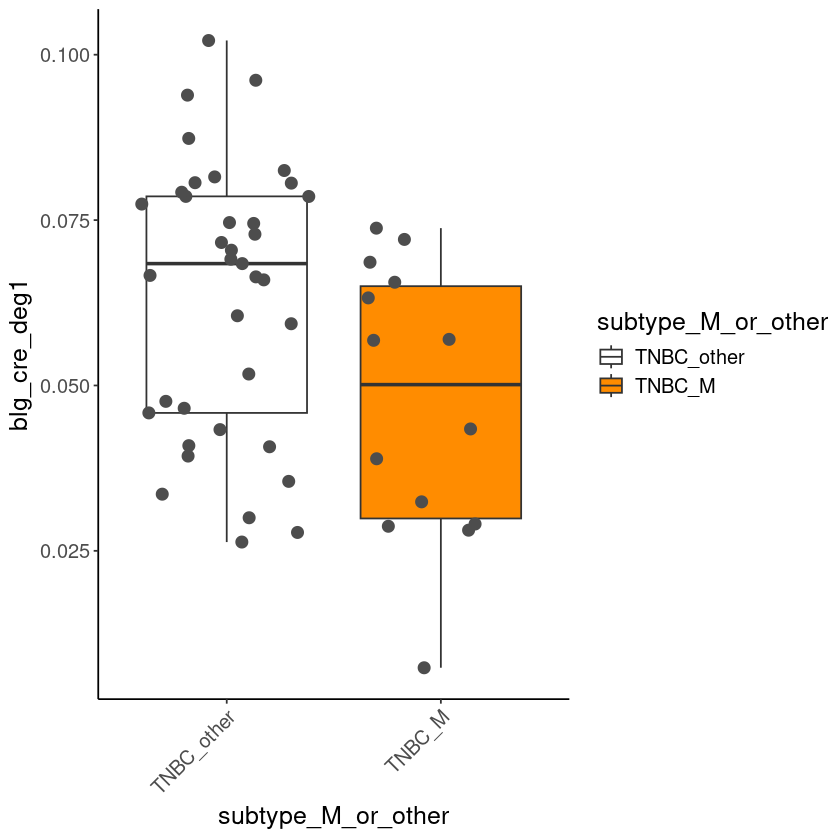

In [66]:
#pdf("blg_score_by_subtype_M_or_not_violins_median.pdf",width=8, height=7)
ggplot(data = bulk_brca1[[]], aes(x=subtype_M_or_other, y=blg_cre_deg1)) + geom_boxplot(aes(fill=subtype_M_or_other))+ 
theme_classic()+
scale_fill_manual(values=c("white","darkorange"))+
theme(text = element_text(size = 15))+
geom_jitter(alpha = 5, color = "grey30",size=3)+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
#dev.off()

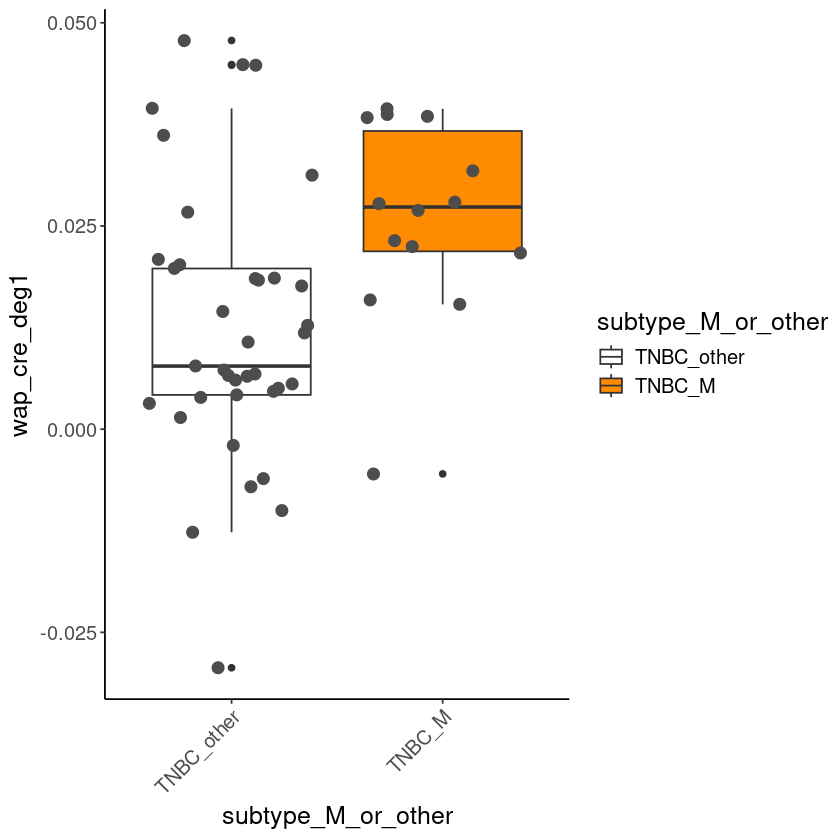

In [19]:
#pdf("blg_score_by_subtype_M_or_not_violins_median.pdf",width=8, height=7)
ggplot(data = bulk_brca1[[]], aes(x=subtype_M_or_other, y=wap_cre_deg1)) + geom_boxplot(aes(fill=subtype_M_or_other))+ 
theme_classic()+
scale_fill_manual(values=c("white","darkorange"))+
theme(text = element_text(size = 15))+
geom_jitter(alpha = 5, color = "grey30",size=3)+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))
#dev.off()

In [20]:
df <- bulk_brca1[[]]

m <- df[which(df$final_subtype == "M"),]
e <- df[which(df$final_subtype != "M"),] 

t.test(m$wap_cre_deg1,e$wap_cre_deg1,alternative = c("two.sided"))


	Welch Two Sample t-test

data:  m$wap_cre_deg1 and e$wap_cre_deg1
t = 3.1775, df = 32.117, p-value = 0.003277
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 0.004865709 0.022238588
sample estimates:
 mean of x  mean of y 
0.02589028 0.01233813 


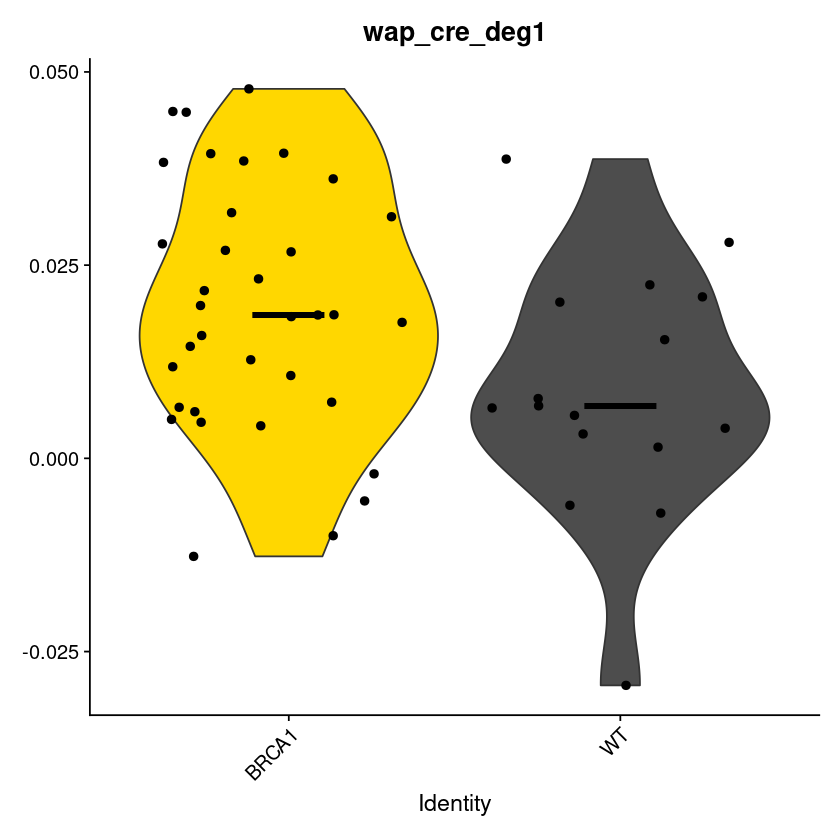

In [21]:
#pdf("blg_score_by_mutation_violins_median.pdf")
VlnPlot(bulk_brca1, "wap_cre_deg1", group.by = "Mutation",cols=c("gold","grey30"), pt.size=2)+
    stat_summary(fun = median, geom='point', size = 25, colour = "black", shape = 95)+NoLegend()
#dev.off()

In [22]:
m <- df[which(df$Mutation == "BRCA1"),]
e <- df[which(df$Mutation != "BRCA1"),] 

t.test(m$wap_cre_deg1,e$wap_cre_deg1,alternative = c("two.sided"))


	Welch Two Sample t-test

data:  m$wap_cre_deg1 and e$wap_cre_deg1
t = 2.2404, df = 29.251, p-value = 0.03283
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 0.0009455067 0.0206802156
sample estimates:
  mean of x   mean of y 
0.019450595 0.008637734 


In [23]:
df <- bulk_brca1[[]]

In [24]:
one.way <- aov(wap_cre_deg1 ~ subtype_mutation_other, data = df)
summary(one.way)

                       Df   Sum Sq   Mean Sq F value Pr(>F)  
subtype_mutation_other  2 0.001866 0.0009329   3.737  0.031 *
Residuals              48 0.011983 0.0002497                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [25]:
saveRDS(bulk_brca1, "final_brca1_wt_tumors_seurat5.rds")